<a href="https://colab.research.google.com/github/sholava/Titanic/blob/main/Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**CheckPoint1**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot stili
sns.set_theme(style="whitegrid")

# Titanic dataset-ini oxuyuruq
df = pd.read_csv("Titanic.csv")

# 1. Datanın ölçüsü (sətir və sütun sayı)
print("--- Shape ---")
print(df.shape)

# 2. Sütunların tipləri və mənimsənilmiş dəyərlər
print("\n--- Info ---")
df.info()

# 3. Boş dəyərlərin sayı
print("\n--- Missing Values ---")
print(df.isnull().sum())

# 4. Dublikat sətirlərin sayı
print("\n--- Duplicates ---")
print(df.duplicated().sum())

--- Shape ---
(891, 12)

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

--- Missing Values ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare       

**Checkpoint2**

In [4]:
# 1. 'Age' (Yaş) sütunu: Pclass (bilet dərəcəsi) üzrə median ilə doldurmaq daha dəqiqdir
df['Age'] = df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))

# 2. 'Embarked' sütunu: Kateqorik olduğu üçün Mode (ən çox təkrar olunan) ilə doldururuq
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 3. 'Cabin' sütunu: Çox böyük hissəsi (70%+)-i boş olduğu üçün silmək əvəzinə 'Unknown' yazırıq
df['Cabin'] = df['Cabin'].fillna('Unknown')

# Yoxlayırıq ki, boş dəyər qaldı ya yox
print("Doldurulduqdan sonra boş dəyərlərin sayı:")
print(df.isnull().sum())

Doldurulduqdan sonra boş dəyərlərin sayı:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


**CheckPoint 3**

Fare sütunundakı outlier sayısı: 116
Age sütunundakı outlier sayısı: 26


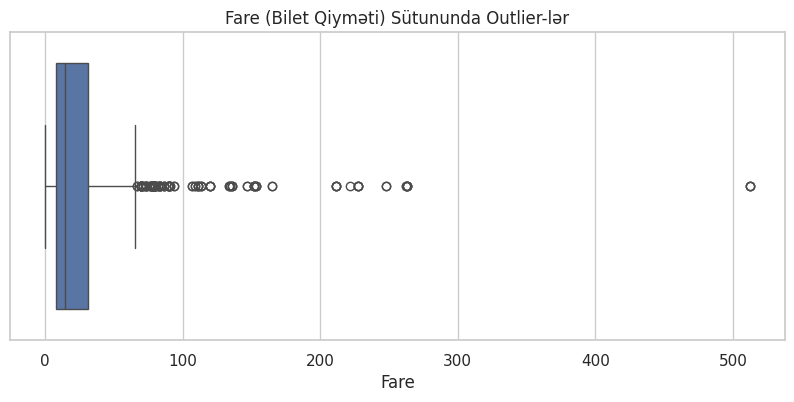

Fare sütunundakı kənar dəyərlər IQR yuxarı sərhədinə sıxışdırıldı.


In [5]:
# 1. IQR (Interquartile Range) metodu ilə 'Fare' və 'Age' üçün Outlier-lərin hesablanması
for col in ['Fare', 'Age']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col} sütunundakı outlier sayısı: {len(outliers)}")

# 2. Outlier-lərin vizuallaşdırılması (Boxplot)
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Fare'])
plt.title("Fare (Bilet Qiyməti) Sütununda Outlier-lər")
plt.show()

# 3. Capping (yuxarı sərhədə sıxışdırma) metodu ilə tənzimlənməsi
Q1_fare = df['Fare'].quantile(0.25)
Q3_fare = df['Fare'].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare
upper_fare = Q3_fare + 1.5 * IQR_fare

# Bilet qiymətindəki kənar dəyərlər yuxarı sərhədə sıxışdırılır
df['Fare_clean'] = np.where(df['Fare'] > upper_fare, upper_fare, df['Fare'])
print("Fare sütunundakı kənar dəyərlər IQR yuxarı sərhədinə sıxışdırıldı.")

**CheckPoint 4**

In [8]:
# 1. FamilySize: Ailə üzvlərinin ümumi sayı
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# 2. IsAlone: Sərnişin tək səyahət edir ya yox? (1 = Təkdir, 0 = Ailəlidir)
df['IsAlone'] = np.where(df['FamilySize'] == 1, 1, 0)

# 3. Title: Ad sütunundan titulların (Mr, Mrs, Miss və s.) çıxarılması

df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# Nadir titulları 'Rare' kateqoriyasında birləşdirək və bəzilərini standartlaşdıraq
df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr',
                                   'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

# Yaranan yeni sütunlara baxaq
print("Yaradılan yeni sütunlar uğurla əlavə olundu:")
print(df[['Name', 'Title', 'FamilySize', 'IsAlone']].head())

Yaradılan yeni sütunlar uğurla əlavə olundu:
                                                Name Title  FamilySize  \
0                            Braund, Mr. Owen Harris    Mr           2   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...   Mrs           2   
2                             Heikkinen, Miss. Laina  Miss           1   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)   Mrs           2   
4                           Allen, Mr. William Henry    Mr           1   

   IsAlone  
0        0  
1        0  
2        1  
3        0  
4        1  


**CheckPoint 5 Vizuallasdirma**

/tmp/ipykernel_534/1827216957.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Title', palette='Set3')


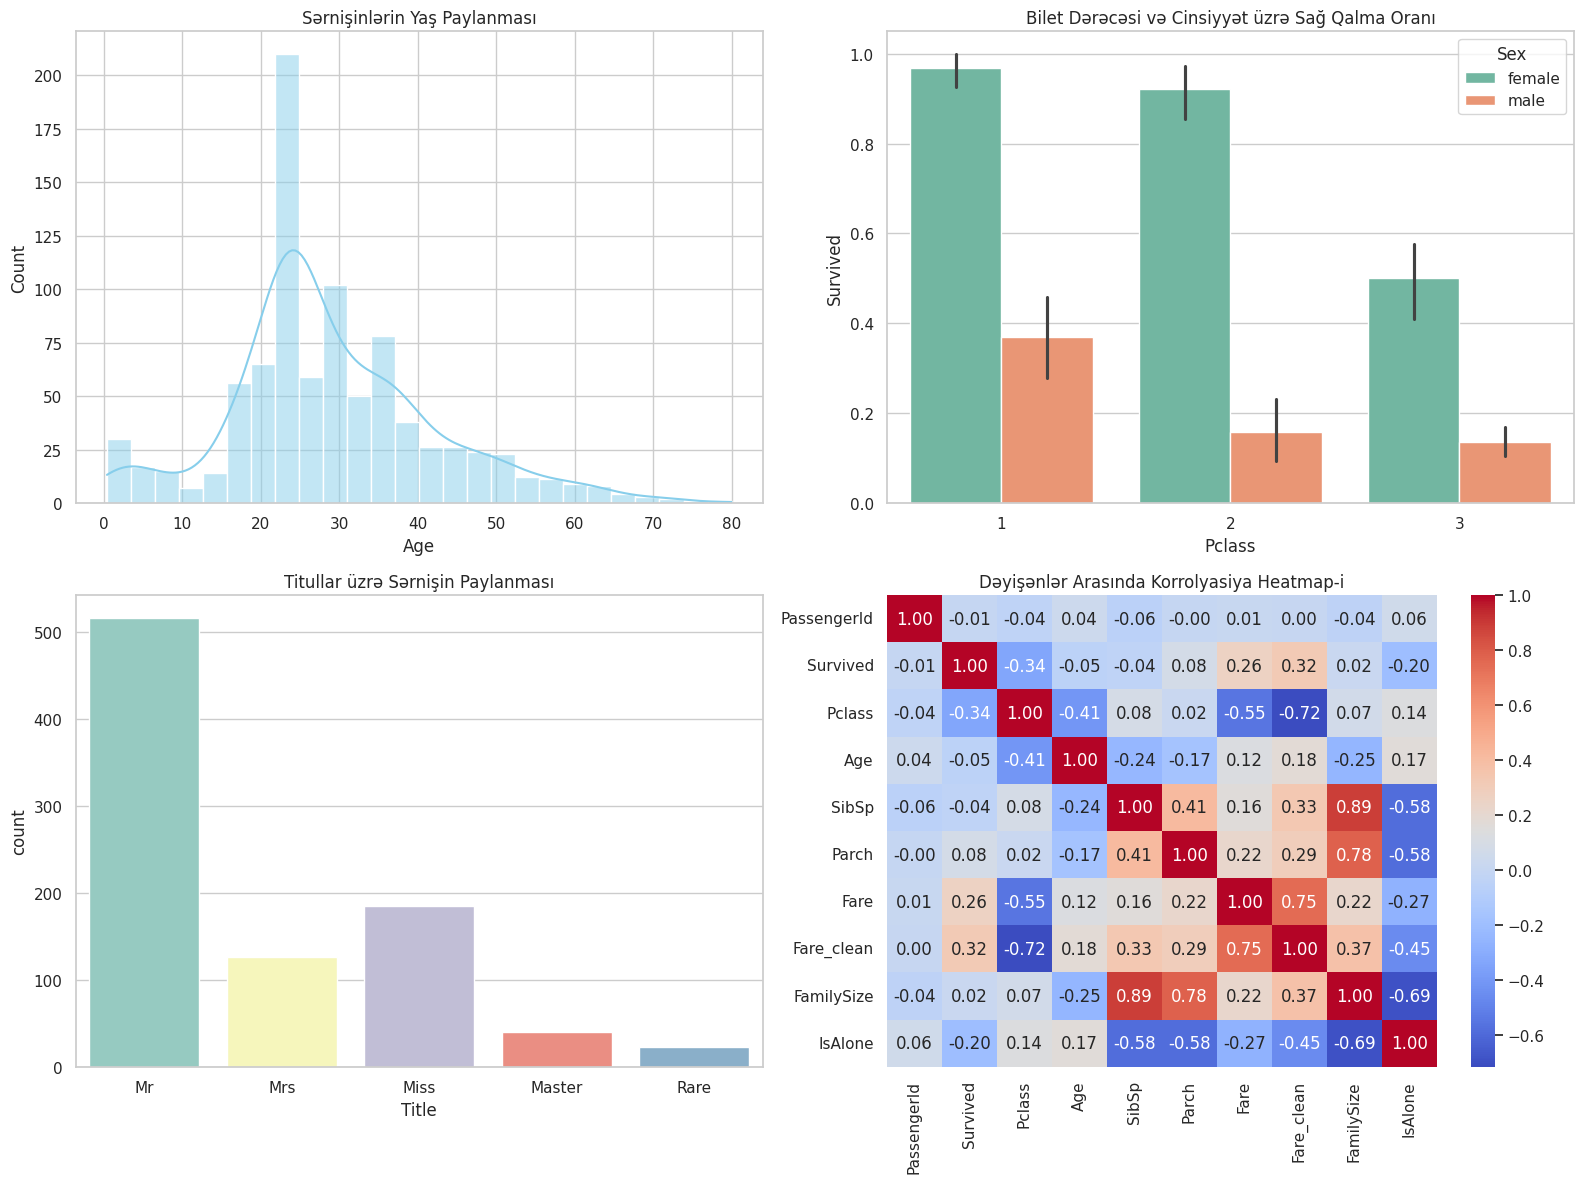

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Şəkillərin ölçüsü və stili
plt.figure(figsize=(16, 12))

# 1. Yaş Paylanması (Histplot)
plt.subplot(2, 2, 1)
sns.histplot(df['Age'], kde=True, color='skyblue')
plt.title('Sərnişinlərin Yaş Paylanması')

# 2. Cinsiyyət və Pclass üzrə Sağ Qalma Nisbəti (Barplot)
plt.subplot(2, 2, 2)
sns.barplot(data=df, x='Pclass', y='Survived', hue='Sex', palette='Set2')
plt.title('Bilet Dərəcəsi və Cinsiyyət üzrə Sağ Qalma Oranı')

# 3. Titullar üzrə Sərnişin Sayı (Countplot)
plt.subplot(2, 2, 3)
sns.countplot(data=df, x='Title', palette='Set3')
plt.title('Titullar üzrə Sərnişin Paylanması')

# 4. Ədədi Sütunların Korrolyasiya Xəritəsi (Heatmap)
plt.subplot(2, 2, 4)
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Dəyişənlər Arasında Korrolyasiya Heatmap-i')

plt.tight_layout()
plt.show()